[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/microscopy-processing/N2N-REO/blob/main/N2N-REO.ipynb)

# N2N-REO (Noise2Noise Registered Even Odd) tomomgram denoising

## Packages

In [1]:
# pip install mrcfile
import mrcfile

In [2]:
# pip install numpy
import numpy as np

In [3]:
# pip install tqdm ipywidgets
from tqdm.notebook import tqdm

In [4]:
# pip install matplotlib
import matplotlib.pyplot as plt

In [5]:
# pip install opencv-python
import cv2

In [6]:
import json

In [7]:
# pip install tensorflow

In [8]:
# pip install cryoCARE --no-deps

In [9]:
# pip install csbdeep

In [10]:
# pip install gdown
import gdown

## Download a noisy tomogram

In [11]:
#url="https://drive.google.com/file/d/1UtFnrgTj0JE0wF3GfPNF8BBWat83j0U_/view?usp=drive_link
url="https://drive.google.com/file/d/1DZzmeJtso8woza4bPgQfUezBnTZrufuL/view?usp=sharing"
gdown.download(url, output="noisy_vol.mrc", quiet=False, use_cookies=False)

Downloading...
From: https://drive.google.com/uc?id=1DZzmeJtso8woza4bPgQfUezBnTZrufuL
To: /home/vruiz/repos/N2N-REO/noisy_vol.mrc
100%|█████████████████████████████████████████████████████████████████████████████████████| 56.0M/56.0M [00:01<00:00, 47.8MB/s]


'noisy_vol.mrc'

In [12]:
!ls -l noisy_vol.mrc

-rw------- 1 vruiz vruiz 56001024 jun 18 13:19 noisy_vol.mrc


In [13]:
X = mrcfile.open("noisy_vol.mrc").data

In [14]:
X.shape

(56, 500, 500)

## Split the tomogram in even and odd axial slices

In [15]:
even_vol = X[0::2,:,:]
with mrcfile.new("even.mrc", overwrite=True) as mrc:
    mrc.set_data(even_vol)
    mrc.data

In [16]:
even_vol.shape

(28, 500, 500)

In [17]:
!ls -l "even.mrc"

-rw-r--r-- 1 vruiz vruiz 28001024 jun 18 23:38 even.mrc


In [18]:
odd_vol = X[1::2,:,:]
with mrcfile.new("odd.mrc", overwrite=True) as mrc:
    mrc.set_data(odd_vol)
    mrc.data
    mrc.data

In [19]:
odd_vol.shape

(28, 500, 500)

In [20]:
!ls -l "odd.mrc"

-rw-r--r-- 1 vruiz vruiz 28001024 jun 18 23:38 odd.mrc


## Register the even and odd tomograms by axial slices

In [21]:
farneback_params = dict(
    pyr_scale=0.5,
    levels=3,
    winsize=15,
    iterations=3,
    poly_n=5,
    poly_sigma=1.2,
    flags=0
)

In [22]:
projected_vol = np.zeros_like(odd_vol, dtype=np.float32)

In [23]:
for z in tqdm(range(even_vol.shape[0]), desc="Projecting Slices"):

    # Calculate the dense optical flow from slice_z_plus_1 to slice_z
    flow = cv2.calcOpticalFlowFarneback(even_vol[z, ...], odd_vol[z, ...], None, **farneback_params)
    
    # Create a remapping grid from the flow field
    height, width = flow.shape[:2]
    x_coords, y_coords = np.meshgrid(np.arange(width), np.arange(height))
    
    # The new map tells where each pixel in the output image should come from in the input image
    map_x = (x_coords + flow[..., 0]).astype(np.float32)
    map_y = (y_coords + flow[..., 1]).astype(np.float32)

    # Warp the *original float32 slice* using the map for maximum precision
    original_slice_to_warp = odd_vol[z , ...]
    projected_slice = cv2.remap(
        src=original_slice_to_warp,
        map1=map_x,
        map2=map_y,
        #interpolation=cv2.INTER_LINEAR,
        interpolation=cv2.INTER_NEAREST,
        borderMode=cv2.BORDER_REPLICATE # Handle edge pixels
    )
    
    # Store the result
    projected_vol[z, ...] = projected_slice

Projecting Slices:   0%|          | 0/28 [00:00<?, ?it/s]

In [24]:
projected_vol.shape

(28, 500, 500)

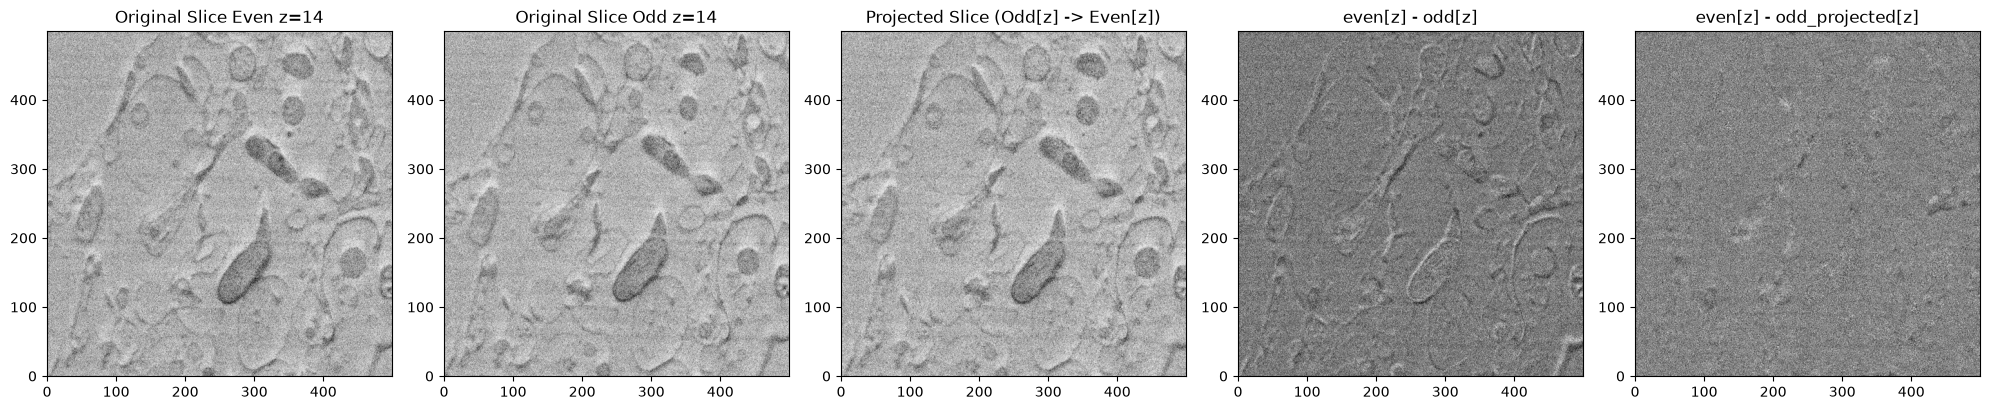

In [25]:
slice_idx = even_vol.shape[0] // 2

fig, axes = plt.subplots(1, 5, figsize=(20, 20))

im1 = axes[0].imshow(even_vol[slice_idx, ...].T, cmap='gray', origin='lower')
axes[0].set_title(f'Original Slice Even z={slice_idx}')
axes[0].grid(False)

im2 = axes[1].imshow(odd_vol[slice_idx, ...].T, cmap='gray', origin='lower')
axes[1].set_title(f'Original Slice Odd z={slice_idx}')
axes[1].grid(False)

im3 = axes[2].imshow(projected_vol[slice_idx, ...].T, cmap='gray', origin='lower')
axes[2].set_title(f'Projected Slice (Odd[z] -> Even[z])')
axes[2].grid(False)

im4 = axes[3].imshow((even_vol[slice_idx, ...].T - odd_vol[slice_idx, ...].T + 128).astype(np.int16), cmap='gray', origin='lower')
axes[3].set_title(f'even[z] - odd[z]')
axes[3].grid(False)

im5 = axes[4].imshow((even_vol[slice_idx, ...].T - projected_vol[slice_idx, ...].T + 128).astype(np.int16), cmap='gray', origin='lower')
axes[4].set_title(f'even[z] - odd_projected[z]')
axes[4].grid(False)

plt.tight_layout()
plt.show()

In [26]:
output_filename = 'odd_registered.mrc'
with mrcfile.new(output_filename, overwrite=True) as mrc:
    mrc.set_data(projected_vol)
    mrc.data
    mrc.data

In [27]:
!ls -l odd_registered.mrc

-rw-r--r-- 1 vruiz vruiz 28001024 jun 18 23:38 odd_registered.mrc


In [28]:
for z in tqdm(range(even_vol.shape[0]), desc="Projecting Slices"):

    # Calculate the dense optical flow from slice_z_plus_1 to slice_z
    flow = cv2.calcOpticalFlowFarneback(odd_vol[z, ...], even_vol[z, ...], None, **farneback_params)
    
    # Create a remapping grid from the flow field
    height, width = flow.shape[:2]
    x_coords, y_coords = np.meshgrid(np.arange(width), np.arange(height))
    
    # The new map tells where each pixel in the output image should come from in the input image
    map_x = (x_coords + flow[..., 0]).astype(np.float32)
    map_y = (y_coords + flow[..., 1]).astype(np.float32)

    # Warp the *original float32 slice* using the map for maximum precision
    original_slice_to_warp = even_vol[z , ...]
    projected_slice = cv2.remap(
        src=original_slice_to_warp,
        map1=map_x,
        map2=map_y,
        #interpolation=cv2.INTER_LINEAR,
        interpolation=cv2.INTER_NEAREST,
        borderMode=cv2.BORDER_REPLICATE # Handle edge pixels
    )
    
    # Store the result
    projected_vol[z, ...] = projected_slice

Projecting Slices:   0%|          | 0/28 [00:00<?, ?it/s]

In [29]:
projected_vol.shape

(28, 500, 500)

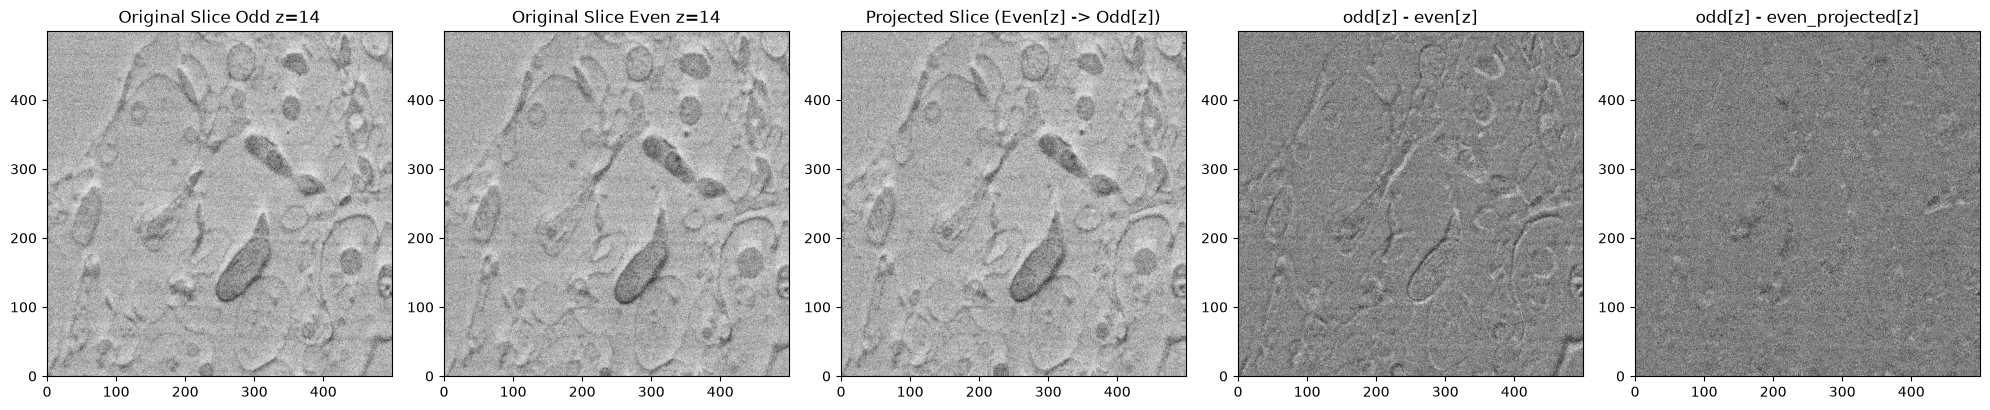

In [30]:
slice_idx = even_vol.shape[0] // 2

fig, axes = plt.subplots(1, 5, figsize=(20, 20))

im1 = axes[0].imshow(odd_vol[slice_idx, ...].T, cmap='gray', origin='lower')
axes[0].set_title(f'Original Slice Odd z={slice_idx}')
axes[0].grid(False)

im2 = axes[1].imshow(even_vol[slice_idx, ...].T, cmap='gray', origin='lower')
axes[1].set_title(f'Original Slice Even z={slice_idx}')
axes[1].grid(False)

im3 = axes[2].imshow(projected_vol[slice_idx, ...].T, cmap='gray', origin='lower')
axes[2].set_title(f'Projected Slice (Even[z] -> Odd[z])')
axes[2].grid(False)

im4 = axes[3].imshow(odd_vol[slice_idx, ...].T - even_vol[slice_idx, ...].T, cmap='gray', origin='lower')
axes[3].set_title(f'odd[z] - even[z]')
axes[3].grid(False)

im5 = axes[4].imshow(odd_vol[slice_idx, ...].T - projected_vol[slice_idx, ...].T, cmap='gray', origin='lower')
axes[4].set_title(f'odd[z] - even_projected[z]')
axes[4].grid(False)

plt.tight_layout()
plt.show()

In [31]:
output_filename = 'even_registered.mrc'
print("Writing", output_filename)

with mrcfile.new(output_filename, overwrite=True) as mrc:
    mrc.set_data(projected_vol)
    mrc.data

Writing even_registered.mrc


In [32]:
!ls -l even_registered.mrc

-rw-r--r-- 1 vruiz vruiz 28001024 jun 18 23:38 even_registered.mrc


# Denoising

In [33]:
_ = {
    "even": ["even.mrc", "even_registered.mrc"],
    "odd": ["odd_registered.mrc", "odd.mrc"],
    "mask": [""],
    "patch_shape": [8, 8, 8], # <- Be careful here: in this example the tomogram is very small and the patch shape must be also small
    "num_slices": 800,
    "split": 0.9,
    "tilt_axis": "Y",
    "n_normalization_samples": 200,
    "path": "./data_REO",
    "overwrite": "True"  
}

with open("train_data_config__REO.json", 'w') as f:
    json.dump(_, f, indent=4)

In [34]:
%%bash
cryoCARE_extract_train_data.py --conf train_data_config__REO.json

I0000 00:00:1781818687.656012   75994 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781818687.656154   75994 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781818687.683076   75994 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781818688.813907   75994 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Computing normalization parameters:


100%|██████████| 200/200 [00:00<00:00, 11443.74it/s]


In [35]:
%%writefile train_config__REO.json
{
  "train_data": "./data_REO",
  "epochs": 50,
  "steps_per_epoch": 200,
  "batch_size": 16,
  "unet_kern_size": 3,
  "unet_n_depth": 3,
  "unet_n_first": 16,
  "learning_rate": 0.0004,
  "model_name": "model_REO",
  "path": "./",
  "gpu_id": [0]
}

Writing train_config__REO.json


In [36]:
%%bash
cryoCARE_train.py --conf train_config__REO.json

I0000 00:00:1781818690.673483   76037 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781818690.673665   76037 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781818690.715601   76037 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781818691.927930   76037 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Looking for GPU with ID: 0
0 1
1 8
2 8
3 8
4 1
Epoch 1/50


E0000 00:00:1781818695.319336   76037 util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.0424 - mae: 0.8079 - mse: 1.0424

/home/vruiz/envs/N2N-REO/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


...

W0000 00:00:1781818921.019271   76037 dataset.cc:997] Input of GeneratorDatasetOp::Dataset will not be optimized because the dataset does not implement the AsGraphDefInternal() method needed to apply optimizations.


200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.7192 - mae: 0.6747 - mse: 0.7192 - val_loss: 0.7651 - val_mae: 0.6969 - val_mse: 0.7651 - learning_rate: 1.0000e-04
Epoch 43/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.7195 - mae: 0.6750 - mse: 0.7195 - val_loss: 0.7589 - val_mae: 0.6931 - val_mse: 0.7589 - learning_rate: 1.0000e-04
Epoch 44/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.7194 - mae: 0.6749 - mse: 0.7194 - val_loss: 0.7622 - val_mae: 0.6939 - val_mse: 0.7622 - learning_rate: 1.0000e-04
Epoch 45/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.7200 - mae: 0.6752 - mse: 0.7200 - val_loss: 0.7683 - val_mae: 0.6970 - val_mse: 0.7683 - learning_rate: 1.0000e-04
Epoch 46/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.7173 - mae: 0.6741 - mse: 0.7173 - val_loss: 0.7735 - val_mae: 0.6995 - val_mse: 0.7735 - learning_rate: 1.0000e-04
Epoch 47/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.7176 - mae: 0.6742 - mse: 0.7176 - val_loss: 0.7

W0000 00:00:1781818954.953013   76037 dataset.cc:997] Input of GeneratorDatasetOp::Dataset will not be optimized because the dataset does not implement the AsGraphDefInternal() method needed to apply optimizations.



Epoch 48: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.7146 - mae: 0.6729 - mse: 0.7146 - val_loss: 0.7669 - val_mae: 0.6951 - val_mse: 0.7669 - learning_rate: 1.0000e-04
Epoch 49/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.7163 - mae: 0.6738 - mse: 0.7163 - val_loss: 0.7682 - val_mae: 0.6978 - val_mse: 0.7682 - learning_rate: 5.0000e-05
Epoch 50/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.7135 - mae: 0.6724 - mse: 0.7135 - val_loss: 0.7635 - val_mae: 0.6949 - val_mse: 0.7635 - learning_rate: 5.0000e-05

Loading network weights from 'weights_best.h5'.


W0000 00:00:1781818967.110450   76037 generator_dataset_op.cc:113] Error occurred when finalizing GeneratorDataset iterator: FAILED_PRECONDITION: Python interpreter state is not initialized. The process may be terminated.
	 [[{{node PyFunc}}]]


In [37]:
_ = {
    "path": "./model_REO.tar.gz",
    "even": ["noisy_vol.mrc"], 
    "odd": ["noisy_vol.mrc"],
    "n_tiles": [1,1,1],
    "output": "denoised_vol_REO",
    "overwrite": "True",
    "gpu_id": [0]
}

with open("predict_config__REO.json", 'w') as f:
    json.dump(_, f, indent=4)

In [38]:
%%bash
cryoCARE_predict.py --conf predict_config__REO.json || true

I0000 00:00:1781818967.836127   82339 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781818967.836266   82339 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781818967.865082   82339 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781818969.128363   82339 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Looking for GPU with ID: 0
Loading network weights from 'weights_best.h5'.
(56, 504, 504, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
['NEWSTACK: Images copied                                  3-Oct-25  17:07:14     '
 'NEWSTACK: Images copied                                 12-Jun-26  15:28:28     '
 'egrate=1\r\nFrameTime=51.1672\r\n\r\n[EScan]\r\nScan=\x00\x00\x00\x00\x00\x00\x00\x00OInterna\x00\x00\x00\x00\x00\x00\x00\x00Oe\r\nDwell=5'
 '-007\r\nPixelWidth=6.74479e-009\r\nPixelHeight=6.74479e-009\r\nHorFieldsize=2.072e-005'
 '\nVerFieldsize=1.38133e-005\r\nFrameTime=51.1672\r\nLineTime=0.024984\r\nMainslock=Off\r'
 'LineIntegration=16\r\nScanInterlacing=1\r\n\r\n[Stage]\r\nStageX=0.00371587\r\nStageY=0.00'
 '293\r\nStageZ=0.00403778\r\nStageR=-1.22169\r\nStageT=0.122173\r\nStageTb=0\r\nSpecTilt=\r\n'
 'orkingDistance=0.00403779\r\nActiveStage=Bulk\r\n\r\n[Image]\r\nDigitalContrast=1\r\nDigit'
 'cryoCARE                                                1

In [39]:
!ls -l denoised_vol_REO/noisy_vol.mrc

-rw-r--r-- 1 vruiz vruiz 56001024 jun 18 23:42 denoised_vol_REO/noisy_vol.mrc


In [40]:
Y = mrcfile.read("denoised_vol_REO/noisy_vol.mrc")

In [41]:
X.shape

(56, 500, 500)

In [42]:
Y.shape

(56, 500, 500)

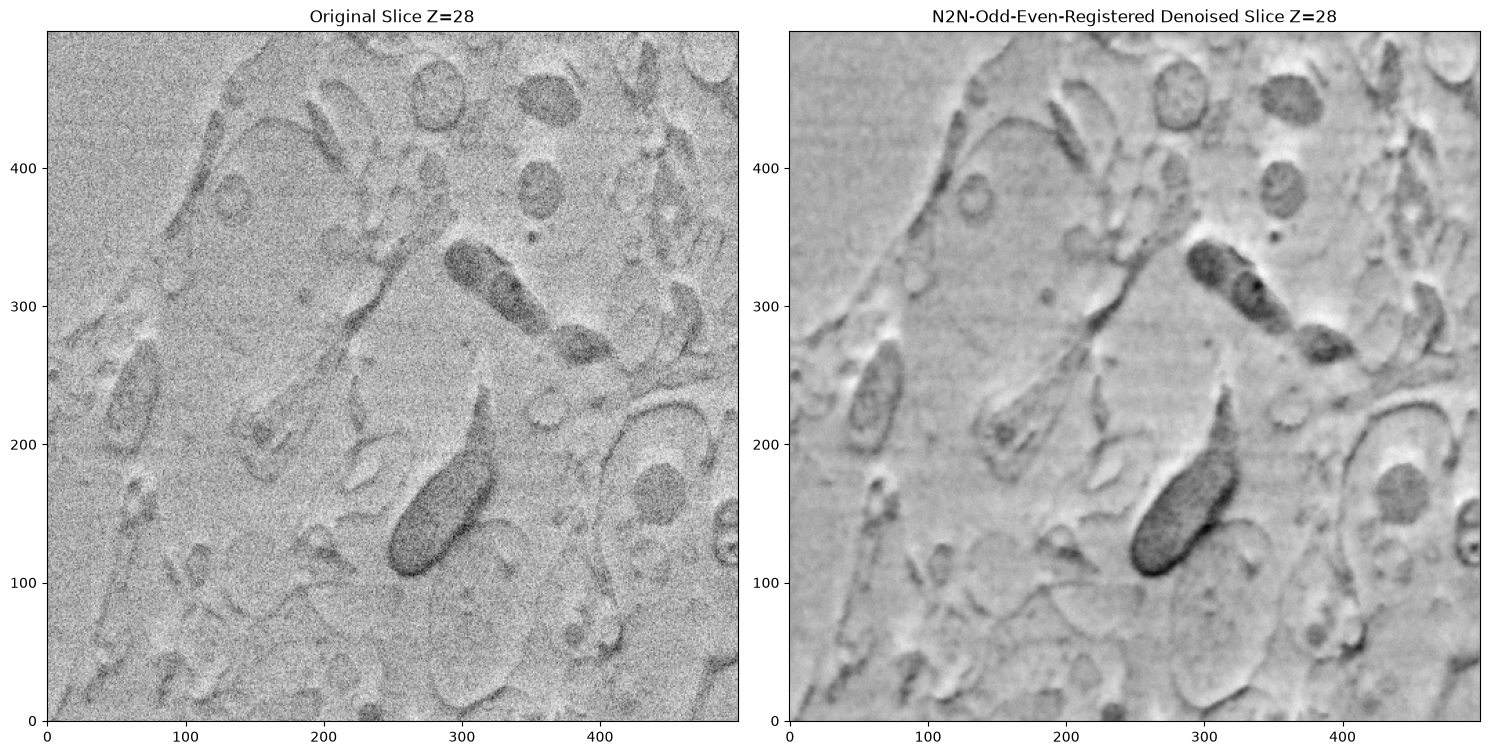

In [43]:
slice_idx = X.shape[0] // 2

fig, axes = plt.subplots(1, 2, figsize=(15, 15))

# Plot a original slice
im1 = axes[0].imshow(X[slice_idx, :, :].T, cmap='gray', origin='lower')
axes[0].set_title(f'Original Slice Z={slice_idx}')
axes[0].grid(False)

# Plot a denoised slice
im2 = axes[1].imshow(Y[slice_idx, :, :].T, cmap='gray', origin='lower')
axes[1].set_title(f'N2N-Odd-Even-Registered Denoised Slice Z={slice_idx}')
axes[1].grid(False)

plt.tight_layout()
plt.show()